In [9]:
# load generated panorama + estimated depth map
import os
import sys
from matplotlib import image
from src.pipeline_flux import FluxPipeline
from src.pipeline_flux_fill import FluxFillPipeline
from diffusers import FluxControlNetModel
from diffusers.pipelines import FluxControlNetPipeline
import torch
import numpy as np
from PIL import Image, ImageOps
import copy
from functools import partial
from scipy.ndimage import maximum_filter, minimum_filter
import logging
from scipy.interpolate import griddata as interp_grid

import my_utils 



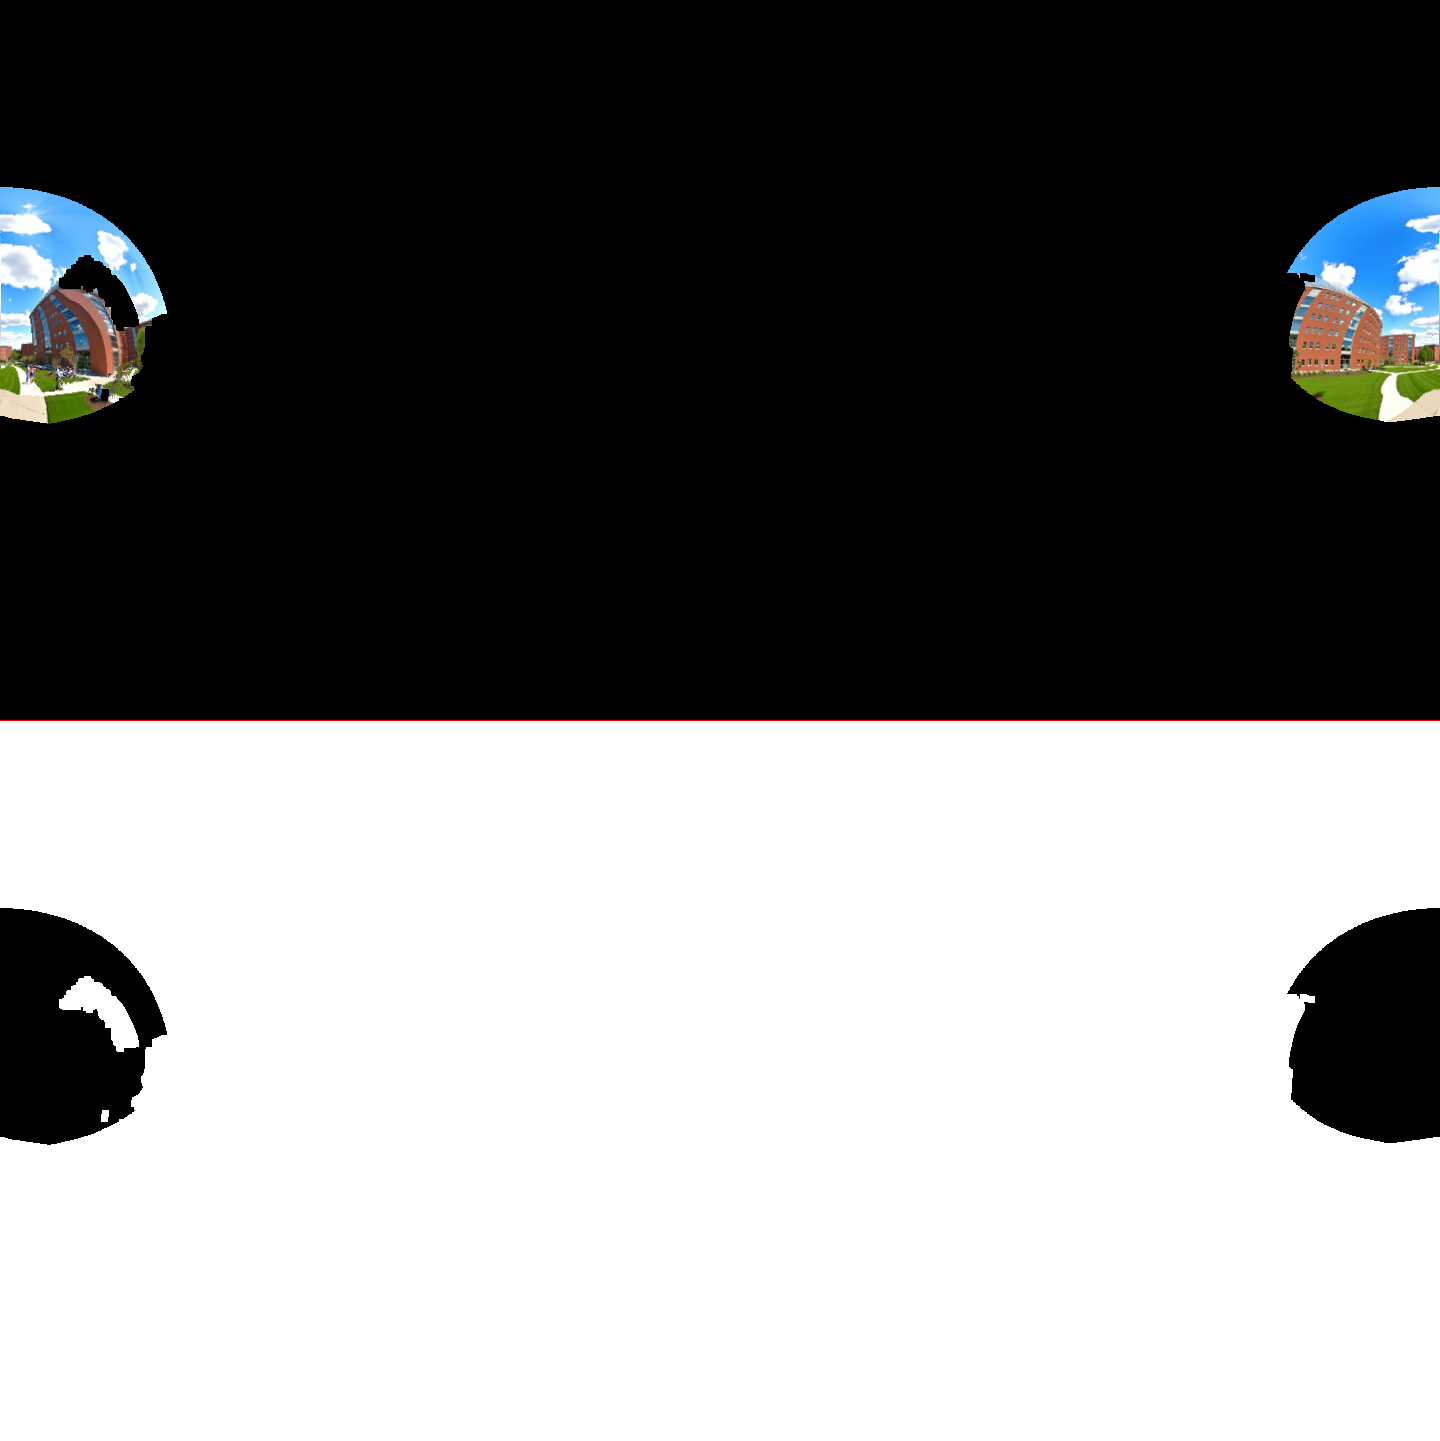

In [10]:

width = 1440
height = 720
flux_lora_pano_path = 'checkpoints/pano_lora_720*1440_v1.safetensors'
image = Image.open("OUTPUTS/SphericalDreamerRecurse/14_campus_cylinder_opening/dream_01/03_warped_img_interp.png").convert('RGB')
mask = Image.open("OUTPUTS/SphericalDreamerRecurse/14_campus_cylinder_opening/dream_01/05_blend1_mask.png").convert('L')
image_arr = np.array(image)

prompt = "A wide panoramic landscape with a bright blue sky, majestic mountains in the background, a calm turquoise sea in the foreground, and lush greenery along the shore. The scene should feel vibrant, sunny, and relaxing, like a holiday postcard photograph, with realistic lighting and high detail."
seed_inpaint = 119224
lora = False
my_utils.tile_image([image, mask])


In [11]:
# init FluxFill pipeline
pano_inpaint_pipeline = FluxFillPipeline.from_pretrained("black-forest-labs/FLUX.1-Fill-dev", torch_dtype=torch.bfloat16)
if lora:
    pano_inpaint_pipeline.load_lora_weights(flux_lora_pano_path, weight_dtype=torch.bfloat16)
pano_inpaint_pipeline.enable_model_cpu_offload()


def inpaint(image, mask_pil, composition=True):

    pano_inpainted = pano_inpaint_pipeline(
        prompt=prompt,
        image=image,  
        mask_image=mask_pil, 
        strength=1.0,
        height=height,
        width=width,
        guidance_scale=30.0,
        num_inference_steps=50,
        max_sequence_length=512,
        generator=torch.Generator("cpu").manual_seed(seed_inpaint),  
    ).images[0]

    # Copy back the masked part of the images in the inpainted image
    if composition:
        composite_mask = ImageOps.invert(mask_pil.convert("L"))
        pano_inpainted_composite = Image.composite(image, pano_inpainted, composite_mask)

        return pano_inpainted, pano_inpainted_composite

    return pano_inpainted

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [12]:
pano_inpainted, pano_inpainted_composite = inpaint(image, mask)

  0%|          | 0/50 [00:00<?, ?it/s]

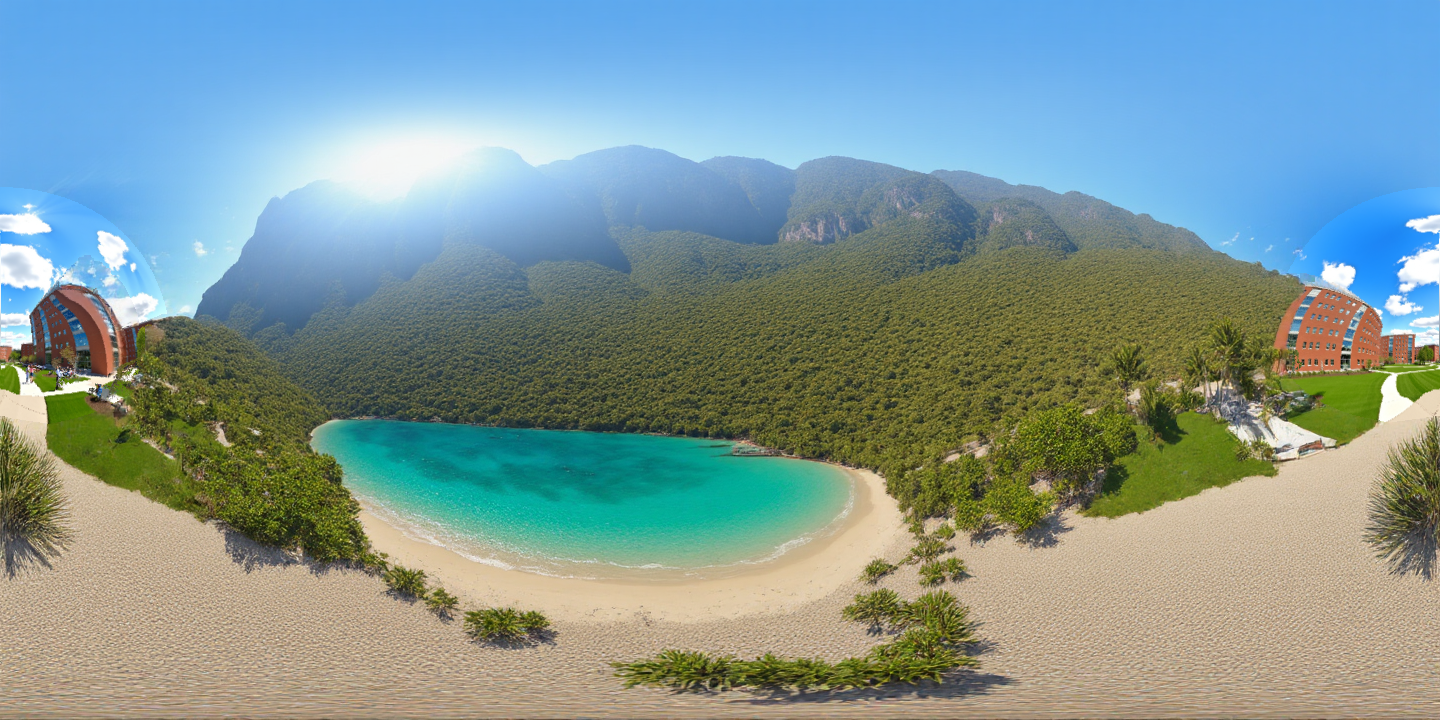

In [14]:
pano_inpainted_composite